In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.shape

(17966, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [7]:
string_cols = df.select_dtypes(include = 'object').columns.tolist()
string_cols

['model', 'transmission', 'fuelType']

In [8]:
for col in string_cols:
    df[col] = df[col].str.strip()

In [9]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [10]:
df['year'].value_counts()

year
2017    4888
2018    4014
2019    3194
2016    2331
2015    1368
2014     805
2013     609
2020     258
2012     115
2011      94
2009      91
2010      67
2008      57
2007      32
2005      16
2006      13
2004       4
2002       3
2003       3
1998       1
1996       1
2000       1
2060       1
Name: count, dtype: int64

In [11]:
df = df[df['year']!=2060]

In [12]:
df.duplicated().sum()

154

In [13]:
df.drop_duplicates(inplace=True)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

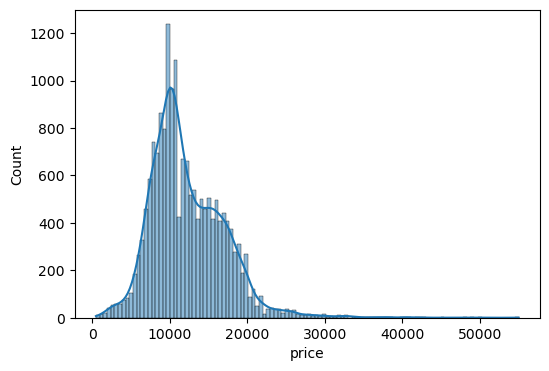

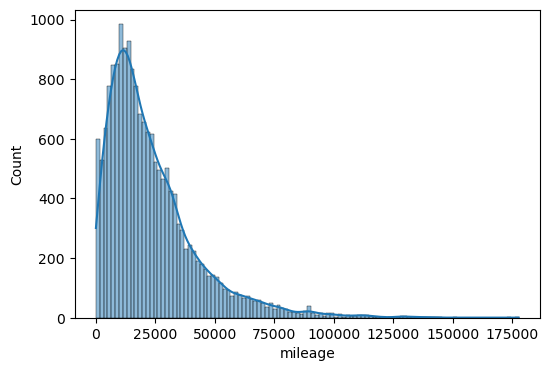

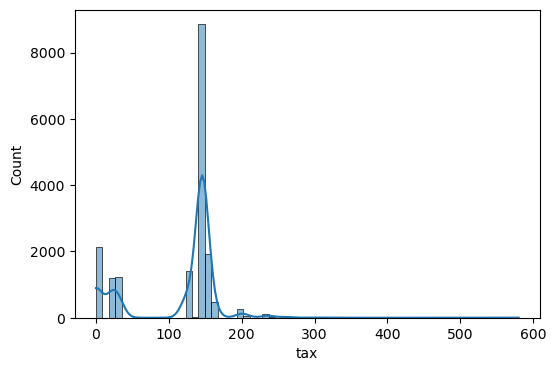

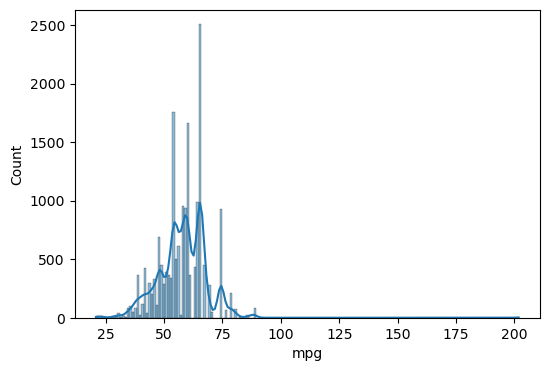

In [14]:
numeric_cols = ['price','mileage','tax','mpg']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

In [15]:
df['engineSize'].value_counts()

engineSize
1.0    7702
1.5    3393
2.0    3273
1.2    1613
1.6     918
1.1     550
1.4     111
2.3      80
0.0      51
5.0      45
1.8      35
2.2      13
2.5      13
1.3      12
3.2       1
1.7       1
Name: count, dtype: int64

In [16]:
mask_condition = df['engineSize'] ==0
median = df[~mask_condition].groupby('model')['engineSize'].median()

In [17]:
median

model
B-MAX                    1.4
C-MAX                    1.5
EcoSport                 1.0
Edge                     2.0
Escort                   1.8
Fiesta                   1.0
Focus                    1.5
Fusion                   1.4
Galaxy                   2.0
Grand C-MAX              1.5
Grand Tourneo Connect    1.5
KA                       1.2
Ka+                      1.2
Kuga                     2.0
Mondeo                   2.0
Mustang                  5.0
Puma                     1.0
Ranger                   3.2
S-MAX                    2.0
Streetka                 1.6
Tourneo Connect          1.5
Tourneo Custom           2.0
Transit Tourneo          2.2
Name: engineSize, dtype: float64

In [18]:
df.loc[mask_condition,'engineSize'] = df.loc[mask_condition,'model'].map(median)
df['engineSize'].fillna(df['engineSize'].median(),inplace=True)

In [19]:
df['mileage'].value_counts()

mileage
15000    38
10       34
25000    33
10000    32
6000     31
         ..
19704     1
8109      1
10794     1
6121      1
23900     1
Name: count, Length: 13527, dtype: int64

In [20]:
q1,q3 = df['mileage'].quantile([0.25,0.75])
iqr = q3-q1
lower, uppper = q1 - 1.5*iqr, q3 + 1.5*iqr
df['mileage'].clip(lower=max(lower,0),upper=uppper,inplace=True)
df['mileage'].value_counts()

/var/folders/tm/p9kq17ps2092tw4nphpl17t40000gr/T/ipykernel_89789/1466470817.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '62731.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df['mileage'].clip(lower=max(lower,0),upper=uppper,inplace=True)


mileage
62731.25    865
15000.00     38
10.00        34
25000.00     33
10000.00     32
           ... 
36333.00      1
44981.00      1
974.00        1
32711.00      1
12210.00      1
Name: count, Length: 12917, dtype: int64

In [21]:
fuel_count = df['fuelType'].value_counts()
fuel_count

fuelType
Petrol      12080
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

In [22]:
rare_fuels = fuel_count[fuel_count<30].index.tolist()
if rare_fuels:
    df['fuelType'].replace(rare_fuels,'Other',inplace=True)
df['fuelType'].value_counts()

fuelType
Petrol    12080
Diesel     5706
Other        25
Name: count, dtype: int64

In [23]:
model_type = df['model'].value_counts()
model_type

model
Fiesta                   6508
Focus                    4556
Kuga                     2208
EcoSport                 1127
C-MAX                     542
Ka+                       523
Mondeo                    512
B-MAX                     350
S-MAX                     294
Grand C-MAX               247
Galaxy                    227
Edge                      205
KA                        197
Puma                       79
Tourneo Custom             69
Mustang                    57
Grand Tourneo Connect      57
Tourneo Connect            32
Fusion                     16
Streetka                    2
Ranger                      1
Escort                      1
Transit Tourneo             1
Name: count, dtype: int64

In [24]:
rare_models = model_type[model_type<30].index.tolist()
if rare_models:
    df['model'].replace(rare_models,'Other',inplace=True)
df['model'].value_counts()

model
Fiesta                   6508
Focus                    4556
Kuga                     2208
EcoSport                 1127
C-MAX                     542
Ka+                       523
Mondeo                    512
B-MAX                     350
S-MAX                     294
Grand C-MAX               247
Galaxy                    227
Edge                      205
KA                        197
Puma                       79
Tourneo Custom             69
Mustang                    57
Grand Tourneo Connect      57
Tourneo Connect            32
Other                      21
Name: count, dtype: int64

In [25]:
df['log_price'] = np.log1p(df['price'])

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

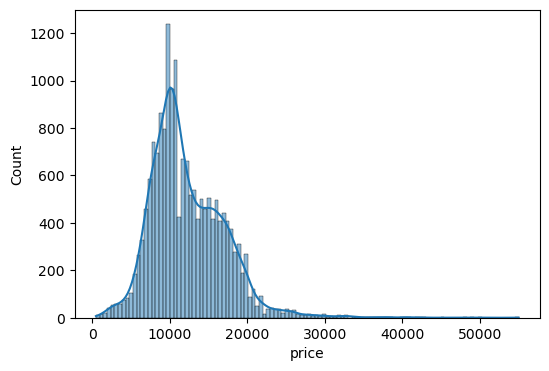

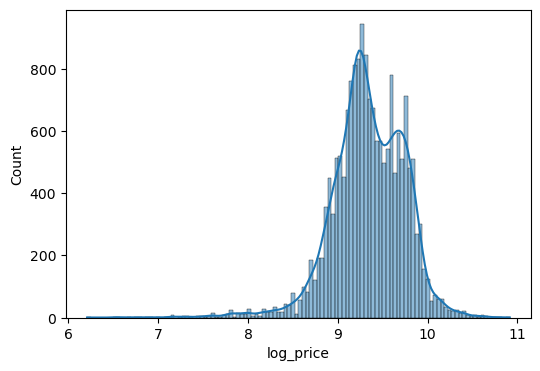

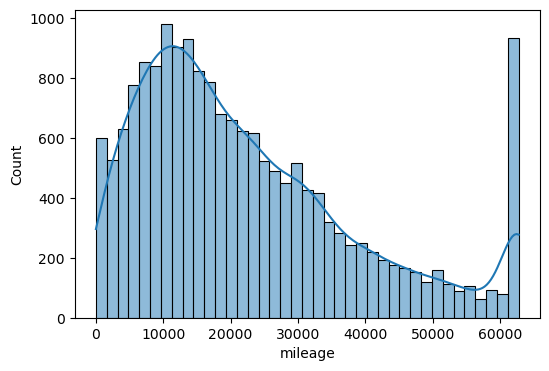

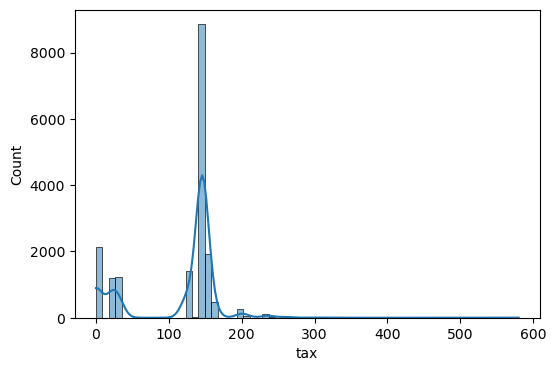

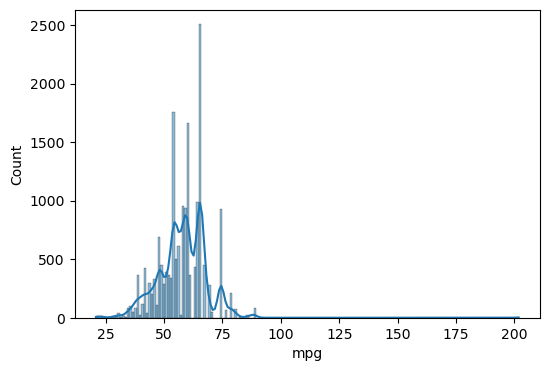

In [26]:
numeric_cols = ['price','log_price','mileage','tax','mpg']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

<Axes: xlabel='transmission', ylabel='price'>

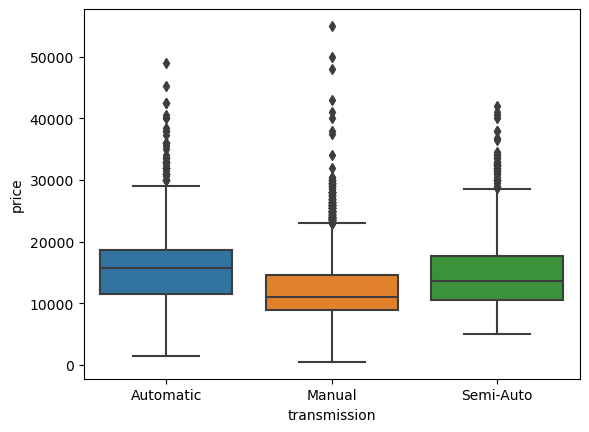

In [27]:
sns.boxplot(df,x='transmission',y='price')

<Axes: xlabel='fuelType', ylabel='price'>

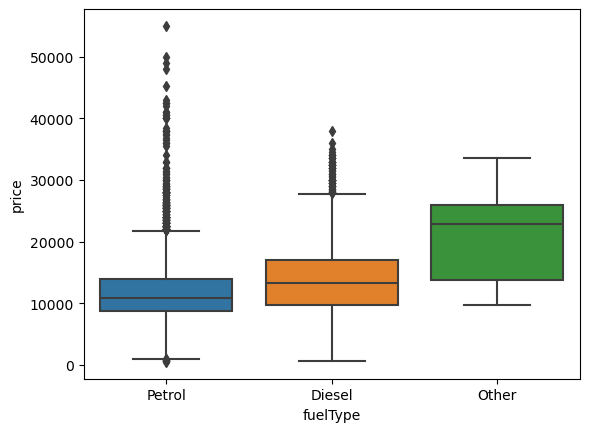

In [28]:
sns.boxplot(df,x='fuelType',y='price')

In [29]:
df.drop(columns=['log_price'],inplace=True)
df.corr(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.645236,-0.710079,0.299192,-0.020195,-0.139869
price,0.645236,1.000000,-0.543462,0.406112,-0.346401,0.416395
mileage,-0.710079,-0.543462,1.000000,-0.304848,0.150034,0.210637
tax,0.299192,0.406112,-0.304848,1.000000,-0.502282,0.187278
mpg,-0.020195,-0.346401,0.150034,-0.502282,1.000000,-0.266827
engineSize,-0.139869,0.416395,0.210637,0.187278,-0.266827,1.000000


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='year', ylabel='price'>

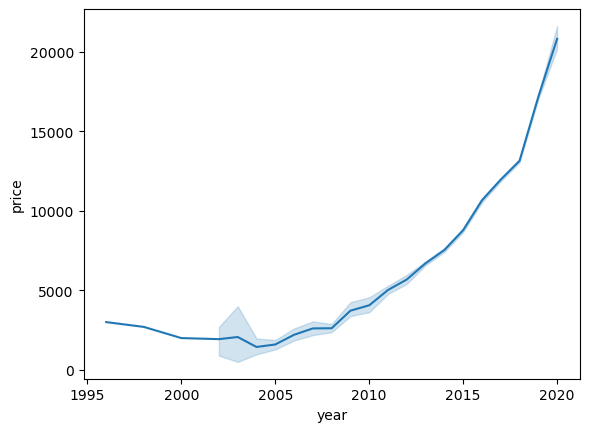

In [30]:
sns.lineplot(data=df, x="year", y="price")

In [31]:
df['car_age']= 2026 - df['year']
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age
0,Fiesta,2017,12000,Automatic,15944.0,Petrol,150,57.7,1.0,9
1,Focus,2018,14000,Manual,9083.0,Petrol,150,57.7,1.0,8
2,Focus,2017,13000,Manual,12456.0,Petrol,150,57.7,1.0,9
3,Fiesta,2019,17500,Manual,10460.0,Petrol,145,40.3,1.5,7
4,Fiesta,2019,16500,Automatic,1482.0,Petrol,145,48.7,1.0,7


In [32]:
df.drop(columns=['year'],inplace=True)

In [33]:
df = pd.get_dummies(data=df,columns=['model','transmission', 'fuelType'], dtype=int, drop_first=True)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [35]:
X = df.drop('price',axis=1)
y = df['price']
X.head()

,mileage,tax,mpg,engineSize,car_age,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,model_Focus,...,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Connect,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol
0,15944.0,150,57.7,1.0,9,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,9083.0,150,57.7,1.0,8,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
2,12456.0,150,57.7,1.0,9,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,10460.0,145,40.3,1.5,7,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
4,1482.0,145,48.7,1.0,7,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


In [36]:
y.head()

0    12000
1    14000
2    13000
3    17500
4    16500
Name: price, dtype: int64

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [38]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae}, RMSE:{rmse}, R2:{r2}")

MAE:1331.4351156910739, RMSE:1785.3068354852333, R2:0.8584119994036217


Try with log price

In [42]:
df['log_price'] = np.log1p(df['price'])
X_log = df.drop(columns=['log_price','price'])
y_log= df['log_price']
X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.33, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae}, RMSE:{rmse}, R2:{r2}")

MAE:1158.224420304379, RMSE:1631.885269868487, R2:0.8817013038428062


In [95]:
from sklearn.linear_model import Ridge, Lasso
df['log_price'] = np.log1p(df['price'])
X_log = df.drop(columns=['log_price','price'])
y_log= df['log_price']
X_train, X_test, y_train, y_test_log = train_test_split(X_log, y_log, test_size=0.33, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_ridge = Ridge(alpha=1.0,random_state=42)
model_ridge.fit(X_train,y_train)
y_pred_log = model_ridge.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae}, RMSE:{rmse}, R2:{r2}")

MAE:1158.2361314572179, RMSE:1631.8452596340817, R2:0.8817071046189112


In [97]:
model_lasso = Lasso(alpha=0.1,random_state=42)
model_lasso.fit(X_train,y_train)
y_pred_log = model_lasso.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae}, RMSE:{rmse}, R2:{r2}")

MAE:2382.5391562851587, RMSE:3329.121025463592, R2:0.5076659410944598


In [99]:
from sklearn.linear_model import RidgeCV, LassoCV
model_ridge_cv = RidgeCV(alphas=(0.01,0.1, 1, 10,100),cv=5)
model_ridge_cv.fit(X_train,y_train)
y_pred_log = model_ridge_cv.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae}, RMSE:{rmse}, R2:{r2}")

MAE:1158.3765774976878, RMSE:1631.5067923579154, R2:0.8817561706950079


In [101]:
model_ridge_cv.alpha_

10.0

In [103]:
model_lasso_cv = LassoCV(alphas=(0.01,0.1, 1, 10,100),cv=5)
model_lasso_cv.fit(X_train,y_train)
y_pred_log = model_lasso_cv.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae}, RMSE:{rmse}, R2:{r2}")
model_lasso_cv.alpha_

MAE:1243.1934502953504, RMSE:1729.2830068850396, R2:0.8671587782832925


0.01